# MedGemma RAG Evaluation on PubMedQA

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Install Dependencies
!pip install -q transformers accelerate bitsandbytes
!pip install -q sentence-transformers faiss-cpu
!pip install -q datasets huggingface_hub
!pip install -q pandas numpy tqdm rouge-score scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
#Imports & Configuration
import os, time, warnings
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import faiss
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
load_dotenv()
from google.colab import userdata
from huggingface_hub import login

CFG = {
    'hf_token' : userdata.get("HF_TOKEN"),
    # Generator
    'generator_model' : 'google/medgemma-4b-it',
    'load_in_4bit'    : True,
    'max_new_tokens'  : 256,
    'temperature'     : 0.1,

    # Retriever
    'retriever_model' : 'sentence-transformers/all-MiniLM-L6-v2',
    'top_k'           : 3,

    # Sampling
    'sample_counts'   : {'yes': 133, 'no': 88, 'maybe': 29},
    'random_seed'     : 42,

    # Output
    'output_path'     : 'medgemma_rag_results.csv',
    'hf_token'        : os.getenv('HF_TOKEN', ''),
}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'Model  : {CFG["generator_model"]}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Model  : google/medgemma-4b-it


In [6]:
import json, os
import pandas as pd
from collections import Counter

# ── Load the files ────────────────────────────────────────────────────────
with open("/content/drive/MyDrive/ori_pqal.json", "r") as f:
    questions_data = json.load(f)

with open("/content/drive/MyDrive/test_ground_truth.json", "r") as f:
    gt_data = json.load(f)

with open("/content/drive/MyDrive/test_ids_250.json", "r") as f:
    raw = json.load(f)
    test_ids = raw.get("test_ids", raw) if isinstance(raw, dict) else raw
    test_ids = [str(i) for i in test_ids]


rows = []
for q_id in test_ids:
    if q_id not in questions_data or q_id not in gt_data:
        print(f"Skipping {q_id} — not found in one of the files")
        continue

    item = questions_data[q_id]

    # ori_pqal.json stores contexts under "CONTEXTS" key as a list
    contexts = item.get("CONTEXTS", [])
    passage  = " ".join(contexts) if isinstance(contexts, list) else str(contexts)

    # Ground truth — handle both dict and plain string formats
    gt = gt_data[q_id]
    label = (gt.get("final_decision", "") if isinstance(gt, dict) else str(gt)).strip().lower()

    rows.append({
        "pubmed_id"      : q_id,
        "question"       : item.get("QUESTION", ""),
        "context"        : passage,
        "long_answer"    : item.get("LONG_ANSWER", ""),
        "final_decision" : label,
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} records")
print("Class distribution:")
print(df["final_decision"].value_counts().to_string())

# Save for reference
df.to_csv("pubmedqa_test_250.csv", index=False)
print("Saved pubmedqa_test_250.csv")
display(df.head(3))

Loaded 250 records
Class distribution:
final_decision
yes      133
no        88
maybe     29
Saved pubmedqa_test_250.csv


,pubmed_id,question,context,long_answer,final_decision
0,10834864,Risk factors for avascular necrosis of bone in...,Avascular necrosis of bone (AVN) is a well kno...,Incorporating an adjustment for corticosteroid...,no
1,11079675,Pulmonary valve replacement in adults late aft...,The purpose of this study is to evaluate right...,Right ventricular recovery following PVR for c...,yes
2,22540518,Is micro-computed tomography reliable to deter...,To analyze the reliability of micro-computed t...,BV/TV assessed by micro-CT correlates with the...,yes


In [7]:
# Build FAISS Retriever
from sentence_transformers import SentenceTransformer
import faiss, numpy as np

print(f"Loading retriever: {CFG['retriever_model']}")
retriever = SentenceTransformer(CFG['retriever_model'])

passages = df['context'].fillna('').tolist()

print(f"Encoding {len(passages)} passages...")
embs = retriever.encode(
    passages, batch_size=32, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True
)

dim   = embs.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embs.astype('float32'))
print(f"FAISS index ready — {index.ntotal} vectors, dim={dim}")


def retrieve(question: str, top_k: int = CFG['top_k']) -> list:
    q_emb = retriever.encode(
        [question], normalize_embeddings=True, convert_to_numpy=True
    ).astype('float32')
    scores, idxs = index.search(q_emb, top_k)
    return [
        {
            'rank'      : r + 1,
            'score'     : float(scores[0][r]),
            'passage'   : passages[idxs[0][r]],
            'pubmed_id' : df.iloc[idxs[0][r]]['pubmed_id'],
        }
        for r in range(top_k)
    ]

# Sanity check
sample_q    = df['question'].iloc[0]
sample_hits = retrieve(sample_q)
print(f"\nSample question: {sample_q[:100]}")
for h in sample_hits:
    print(f"  Rank {h['rank']} | score={h['score']:.3f} | {h['passage'][:80]}...")

Loading retriever: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 250 passages...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

FAISS index ready — 250 vectors, dim=384

Sample question: Risk factors for avascular necrosis of bone in patients with systemic lupus erythematosus: is there 
  Rank 1 | score=0.861 | Avascular necrosis of bone (AVN) is a well known complication in patients with s...
  Rank 2 | score=0.341 | The aetiology of osteochondritis dissecans is still unclear. The aim of this pro...
  Rank 3 | score=0.307 | We investigated the actual role of MRI versus arthroscopy in the detection and c...


In [8]:
#Load MedGemma
from huggingface_hub import login

if CFG['hf_token']:
    login(token=CFG['hf_token'], add_to_git_credential=False)
    print('Logged in to HuggingFace.')
else:
    print('No HF_TOKEN set — model download may fail if gated.')

bnb_config = None
if CFG['load_in_4bit'] and DEVICE == 'cuda':
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    print('4-bit NF4 quantisation enabled.')

print(f'\nLoading {CFG["generator_model"]} …')
t0 = time.time()

tokenizer = AutoTokenizer.from_pretrained(
    CFG['generator_model'], token=CFG['hf_token'] or None
)
model = AutoModelForCausalLM.from_pretrained(
    CFG['generator_model'],
    quantization_config=bnb_config,
    device_map='auto' if DEVICE == 'cuda' else None,
    torch_dtype=torch.bfloat16 if DEVICE == 'cuda' else torch.float32,
    token=CFG['hf_token'] or None,
)
model.eval()
print(f'✅ Loaded in {time.time()-t0:.1f}s')
if DEVICE == 'cuda':
    print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB')

No HF_TOKEN set — model download may fail if gated.
4-bit NF4 quantisation enabled.

Loading google/medgemma-4b-it …


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

✅ Loaded in 453.3s
VRAM used: 3.3 GB


In [9]:
#Prompt Builder & Generation

SYSTEM_PROMPT = """You are a medical research assistant. Answer the clinical question
using ONLY the provided PubMed abstracts. Structure your response as:
1. A short reasoning paragraph citing the evidence.
2. Final decision — exactly one of: yes / no / maybe"""


def build_prompt(question: str, hits: list) -> str:
    ctx = ''.join(
        f"[Passage {h['rank']} | PMID {h['pubmed_id']}]\n{h['passage'].strip()}\n\n"
        for h in hits
    )
    user_msg = (
        f"CONTEXT:\n{ctx.strip()}\n\n"
        f"QUESTION: {question}\n\n"
        "Answer based only on the above context."
    )
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': user_msg},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


@torch.inference_mode()
def generate(prompt: str) -> str:
    inputs = tokenizer(
        prompt, return_tensors='pt', truncation=True, max_length=4096
    ).to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=CFG['max_new_tokens'],
        temperature=CFG['temperature'],
        do_sample=CFG['temperature'] > 0,
        pad_token_id=tokenizer.eos_token_id,
    )
    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def extract_decision(text: str) -> str:
    """Pull out yes/no/maybe from the generated text."""
    t = text.lower()
    for marker in ['final decision:', 'decision:', 'answer:']:
        if marker in t:
            after = t.split(marker)[-1].strip()
            for lbl in ['yes', 'no', 'maybe']:
                if after.startswith(lbl):
                    return lbl
    for lbl in ['yes', 'no', 'maybe']:
        if lbl in t:
            return lbl
    return 'unknown'


# Quick test on the first record
sample_hits   = retrieve(sample_q)
sample_prompt = build_prompt(sample_q, sample_hits)
sample_ans    = generate(sample_prompt)
print('── Sample Answer ──')
print(sample_ans)
print(f'\nExtracted decision : {extract_decision(sample_ans)}')
print(f'True decision      : {df["final_decision"].iloc[0]}')

── Sample Answer ──
The first passage investigates the role of antiphospholipid antibodies in the development of avascular necrosis (AVN) in patients with systemic lupus erythematosus (SLE). The study found no significant differences in the presence of antiphospholipid antibodies between patients with AVN and control groups. The second passage discusses vitamin D insufficiency as a potential etiological factor in osteochondritis dissecans. The third passage discusses the role of MRI versus arthroscopy in the detection of occult bone and/or cartilage injuries in patients with previous musculoskeletal trauma.

Final decision: no

Extracted decision : no
True decision      : no


In [10]:
#Run RAG on All 250 Records

import os

CHECKPOINT_PATH = '/content/drive/MyDrive/rag_checkpoint.csv'
SAVE_EVERY      = 50   # save progress every N records

# ── Resume from checkpoint if it exists ─────────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    results_df  = pd.read_csv(CHECKPOINT_PATH)
    results     = results_df.to_dict('records')
    done_ids    = set(results_df['idx'].tolist())
    print(f'▶️  Resuming from checkpoint — {len(done_ids)} records already done.')
else:
    results  = []
    done_ids = set()
    print('🆕 Starting fresh.')

# ── Main loop ────────────────────────────────────────────────────────────────
t_start = time.time()
print(f'Running RAG on {len(df)} records (top_k={CFG["top_k"]}) …\n')

for i, row in tqdm(df.iterrows(), total=len(df), desc=CFG['generator_model'].split('/')[-1]):

    if i in done_ids:          # skip already-processed records
        continue

    q      = row['question']
    hits   = retrieve(q)
    prompt = build_prompt(q, hits)

    try:
        answer    = generate(prompt)
        predicted = extract_decision(answer)
        err       = None
    except Exception as e:
        answer = ''; predicted = 'error'; err = str(e)

    results.append({
        'idx'               : i,
        'pubmed_id'         : row['pubmed_id'],
        'question'          : q,
        'true_decision'     : row['final_decision'],
        'predicted_decision': predicted,
        'generated_answer'  : answer,
        'retrieved_pmids'   : ' | '.join(str(h['pubmed_id']) for h in hits),
        'retrieval_scores'  : ' | '.join(f"{h['score']:.3f}" for h in hits),
        'error'             : err,
    })

    # ── Save checkpoint every N records ─────────────────────────────────────
    if len(results) % SAVE_EVERY == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
        tqdm.write(f'  💾 Checkpoint saved at record {i}')

# ── Final save ───────────────────────────────────────────────────────────────
elapsed    = time.time() - t_start
results_df = pd.DataFrame(results)
results_df.to_csv(CFG['output_path'], index=False)

# Clean up checkpoint once fully done
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print('🗑️  Checkpoint file removed (run complete).')

print(f'\n✅ Done in {elapsed:.0f}s  ({elapsed/len(df):.1f}s / record)')
print(f'Saved → {CFG["output_path"]}')
display(results_df.head(3))

▶️  Resuming from checkpoint — 50 records already done.
Running RAG on 250 records (top_k=3) …



medgemma-4b-it:   0%|          | 0/250 [00:00<?, ?it/s]

  💾 Checkpoint saved at record 99
  💾 Checkpoint saved at record 149
  💾 Checkpoint saved at record 199
  💾 Checkpoint saved at record 249
🗑️  Checkpoint file removed (run complete).

✅ Done in 3986s  (15.9s / record)
Saved → medgemma_rag_results.csv


,idx,pubmed_id,question,true_decision,predicted_decision,generated_answer,retrieved_pmids,retrieval_scores,error
0,0,10834864,Risk factors for avascular necrosis of bone in...,no,no,The first passage investigates the role of ant...,10834864 | 25371231 | 9465206,0.861 | 0.341 | 0.307,NaN
1,1,11079675,Pulmonary valve replacement in adults late aft...,yes,no,1. The first study (PMID 11079675) investigate...,11079675 | 25810292 | 17306983,0.669 | 0.459 | 0.379,NaN
2,2,22540518,Is micro-computed tomography reliable to deter...,yes,yes,The study in Passage 1 demonstrates a strong p...,22540518 | 24481006 | 26419377,0.699 | 0.440 | 0.348,NaN


═══════════════════════════════════════════════════════
  Model    : google/medgemma-4b-it
  Accuracy : 0.598  (149/249)
  Unknown  : 1
  Errors   : 0
═══════════════════════════════════════════════════════

── Classification Report ──
              precision    recall  f1-score   support

         yes       0.63      0.75      0.68       132
          no       0.56      0.56      0.56        88
       maybe       0.33      0.03      0.06        29

    accuracy                           0.60       249
   macro avg       0.51      0.45      0.43       249
weighted avg       0.57      0.60      0.57       249



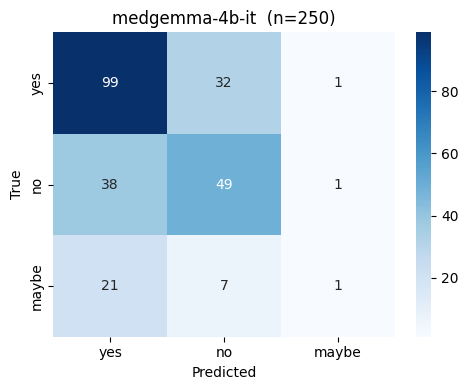

Saved confusion_matrix.png

── ROUGE vs expert long_answer (avg F1) ──
rouge1    0.2697
rouge2    0.0854
rougeL    0.1793


In [13]:
#Evaluation & Metrics
from sklearn.metrics import classification_report, confusion_matrix
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

rdf   = results_df.copy()
valid = rdf[
    rdf['true_decision'].isin(['yes','no','maybe']) &
    ~rdf['predicted_decision'].isin(['error','unknown'])
]

acc = (valid['predicted_decision'] == valid['true_decision']).mean()

print('═'*55)
print(f'  Model    : {CFG["generator_model"]}')
print(f'  Accuracy : {acc:.3f}  ({int(acc*len(valid))}/{len(valid)})')
print(f'  Unknown  : {(rdf["predicted_decision"]=="unknown").sum()}')
print(f'  Errors   : {(rdf["predicted_decision"]=="error").sum()}')
print('═'*55)

print('\n── Classification Report ──')
print(classification_report(
    valid['true_decision'], valid['predicted_decision'],
    labels=['yes','no','maybe'], zero_division=0
))

# Confusion matrix heatmap
labels = ['yes', 'no', 'maybe']
cm = confusion_matrix(valid['true_decision'], valid['predicted_decision'], labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels,
            cmap='Blues', ax=ax)
ax.set_title(f"{CFG['generator_model'].split('/')[-1]}  (n=250)")
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved confusion_matrix.png')

# ROUGE against the expert long_answer
scorer_r = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
r_scores = []
for _, row in rdf.iterrows():
    ref = df.loc[row['idx'], 'long_answer'] if row['idx'] < len(df) else ''
    if row['generated_answer'] and ref:
        s = scorer_r.score(ref, row['generated_answer'])
        r_scores.append({k: v.fmeasure for k, v in s.items()})
if r_scores:
    print('\n── ROUGE vs expert long_answer (avg F1) ──')
    print(pd.DataFrame(r_scores).mean().round(4).to_string())

In [14]:
#Inspect Individual Predictions
def inspect(i: int):
    r  = results_df.iloc[i]
    ok = '✅' if r['predicted_decision'] == r['true_decision'] else '❌'
    print(f"{'─'*60}")
    print(f" PMID       : {r['pubmed_id']}")
    print(f" Question   : {r['question']}")
    print(f" True       : {r['true_decision']}   Predicted: {r['predicted_decision']} {ok}")
    print(f" Retrieved  : {r['retrieved_pmids']}")
    print(f"\n Answer:\n{r['generated_answer']}")
    print(f"{'─'*60}")

for i in range(3):
    inspect(i)

# inspect any specific index:  inspect(42)

────────────────────────────────────────────────────────────
 PMID       : 10834864
 Question   : Risk factors for avascular necrosis of bone in patients with systemic lupus erythematosus: is there a role for antiphospholipid antibodies?
 True       : no   Predicted: no ✅
 Retrieved  : 10834864 | 25371231 | 9465206

 Answer:
The first passage investigates the role of antiphospholipid antibodies in the development of avascular necrosis (AVN) in patients with systemic lupus erythematosus (SLE). The study found no significant differences in the presence of antiphospholipid antibodies between patients with AVN and control groups. The second passage discusses vitamin D insufficiency as a potential etiological factor in osteochondritis dissecans. The third passage discusses the role of MRI versus arthroscopy in the detection of occult bone and/or cartilage injuries in patients with previous musculoskeletal trauma.

Final decision: no
──────────────────────────────────────────────────────────